In [45]:
# Import necessary libraries
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
from termcolor import colored
pio.templates.default = "plotly_white"  # Set a clean theme

# Your Overtaking Model Parameters
DRS_thres = 1.0
DRS_bonus = -0.25
OT_thres = 1.868   #Overtaking threshold / overtaking delta, calc'd via Excel
prob_OT = 0.41    #Overtaking probability, it's calc'd using Poisson process, = 1-e^(ot/laps)
pMin = 0.1      # Minimum probability per lap
overtake_penalty = 0.5
dirty_air_loss = 0.6  # Time loss per lap when following

# Race Parameters
total_laps = 58
pit_time_loss = 22  # seconds
p_SC = 0.28         # Probability of a Safety Car, it's calc'd using Poisson process, = 1-e^(sc /no. of races)
p_VSC = 0.23        # Probability of a VSC, it's calc'd using Poisson process, = 1-e^(vsc /no. of races)
sc_time_saving = 15 # Seconds saved on a pit stop under SC/VSC

# Define the overtaking probability function (as previously discussed)
def get_overtake_probability(delta):
    if delta > DRS_thres:
        return 0.0
    effective_delta = delta + DRS_bonus
    if effective_delta <= 0:
        return 1.0
    elif effective_delta >= OT_thres:
        return pMin
    else:
        p_lap = prob_OT * (1 - (effective_delta / OT_thres))
        return max(p_lap, pMin)

In [47]:
# Define the strategies with my lap time data
ts_stint1 = [85.034470710685, 85.10142180041164, 85.16880586288447, 85.23659576908834, 85.30475805378366, 85.37325309301976, 85.4420354802886, 85.51105460366313, 85.58025541513688, 85.64957937177778, 85.71896551724139, 85.81157851865322, 85.95122190744944, 86.11396609836855, 86.26768812958377, 86.4120909019925, 86.75345802722734, 87.14307289486311]
ts_stint2 = [85.35825288915314, 85.42822856529008, 85.49897327664905, 85.57048157069632, 85.64273934399255, 85.71572315652068, 85.78939972544273, 85.86372564433444, 85.93864736881247, 86.01410150055575, 86.09001538915142, 86.1663080555162, 86.24289142283968, 86.31967182243064, 86.39655172413792, 86.48754407299732, 86.60601903602358, 86.74712297604347, 86.88882510871147, 87.02316331860087, 87.1522386170601, 87.42217869933656]
ts_stint3 = [85.034470710685, 85.10142180041164, 85.16880586288447, 85.23659576908834, 85.30475805378366, 85.37325309301976, 85.4420354802886, 85.51105460366313, 85.58025541513688, 85.64957937177778, 85.71896551724139, 85.81157851865322, 85.95122190744944, 86.11396609836855, 86.26768812958377, 86.4120909019925, 86.75345802722734, 87.14307289486311]

os_stint1 = [85.034470710685, 85.10142180041164, 85.16880586288447, 85.23659576908834, 85.30475805378366, 85.37325309301976, 85.4420354802886, 85.51105460366313, 85.58025541513688, 85.64957937177778, 85.71896551724139, 85.81157851865322, 85.95122190744944, 86.11396609836855, 86.26768812958377, 86.4120909019925, 86.75345802722734, 87.14307289486311, 87.5755596234838, 88.04242658348436, 88.53421090388555, 89.04206911335582, 89.5586989708945, 90.07865453833179, 90.59824308947127, 91.11521046857715]
os_stint2 = [85.35825288915314, 85.42822856529008, 85.49897327664905, 85.57048157069632, 85.64273934399255, 85.71572315652068, 85.78939972544273, 85.86372564433444, 85.93864736881247, 86.01410150055575, 86.09001538915142, 86.1663080555162, 86.24289142283968, 86.31967182243064, 86.39655172413792, 86.48754407299732, 86.60601903602358, 86.74712297604347, 86.88882510871147, 87.02316331860087, 87.1522386170601, 87.42217869933656, 87.72624324044685, 88.06049125117733, 88.41885387802901, 88.7945779798783, 89.18134950006085, 89.57395407143628, 89.96850470519995, 90.36236937603736, 90.75394652580417, 91.14240010398001]

# Pit laps
ts_pit_laps = [18, 40]  # Pit after completing these laps
os_pit_lap = [26]         # Pit after completing this lap

# Create full lap time arrays
ts_lap_times = ts_stint1 + ts_stint2 + ts_stint3
os_lap_times = os_stint1 + os_stint2

# Calculate total free air time (including pit stops)
total_time_ts = sum(ts_lap_times) + (pit_time_loss * 2) # Two stops
total_time_os = sum(os_lap_times) + pit_time_loss         # One stop


print(f"One-Stop Free Air Time: {total_time_os:.3f}s")
total_time_os_min = total_time_os//60
total_time_os_minsec = total_time_os%60
print(f"Two-Stop Free Air Time: {total_time_ts:.3f}s")
total_time_ts_min = total_time_ts//60
total_time_ts_minsec = total_time_ts%60
ini_time_difference = total_time_ts - total_time_os
print(f"Free Air Time Difference: {ini_time_difference:.3f}s (Two-Stop Faster)")


One-Stop Free Air Time: 5070.465s
Two-Stop Free Air Time: 5027.511s
Free Air Time Difference: -42.953s (Two-Stop Faster)


Expected Traffic Loss for Two-Stop: 31.579s


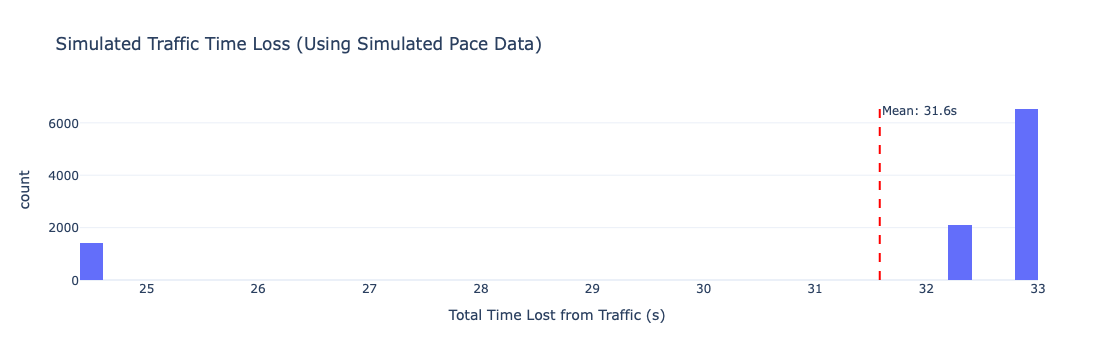

In [49]:
# --- Enhanced Monte Carlo Simulation for Traffic Loss ---
num_simulations = 10000
traffic_loss_results = []

# Assume the car ahead is on a consistent pace. Let's use an average of the two-stopper's pace as reference.
# A more complex model could simulate a specific competitor's strategy.
reference_pace = np.mean(ts_lap_times) 

for _ in range(num_simulations):
    total_traffic_loss = 0
    
    # Simulate traffic after each pit stop for the two-stopper
    for rejoin_lap, cars_to_pass in [(ts_pit_laps[0], 3), (ts_pit_laps[1], 5)]:
        rejoin_lap_index = rejoin_lap # Lap number when rejoining
        for car in range(cars_to_pass):
            # Initial gap after pit stop (x seconds behind)
            gap_to_car_ahead = 3.0
            overtaken = False
            laps_spent = 0
            
            while not overtaken and rejoin_lap_index < total_laps:
                # Get our car's pace advantage on THIS specific lap
                # Our fresh tyre pace vs. reference pace of car ahead
                our_pace = ts_lap_times[rejoin_lap_index] # Our predicted lap time
                pace_delta = reference_pace - our_pace # Positive means we are faster
                
                # Check if we are in DRS range to attempt an overtake
                if gap_to_car_ahead <= DRS_thres:
                    prob = get_overtake_probability(gap_to_car_ahead)
                    if np.random.random() < prob:
                        total_traffic_loss += overtake_penalty
                        overtaken = True
                    else:
                        total_traffic_loss += dirty_air_loss
                else:
                    total_traffic_loss += dirty_air_loss

                # Close the gap for the next lap based on our real pace advantage
                gap_to_car_ahead += pace_delta 
                gap_to_car_ahead = max(0.1, gap_to_car_ahead) # Keep it positive
                
                rejoin_lap_index += 1
                laps_spent += 1
                # Break if it's taking too long (e.g., > 10 laps per car)
                if laps_spent > 15:
                    # print("Gave up overtake")
                    break

    traffic_loss_results.append(total_traffic_loss)

expected_traffic_loss = np.mean(traffic_loss_results)
print(f"Expected Traffic Loss for Two-Stop: {expected_traffic_loss:.3f}s")

# Plot the distribution
fig_traffic = px.histogram(x=traffic_loss_results, nbins=50,
                          title='Simulated Traffic Time Loss (Using Simulated Pace Data)',
                          labels={'x': 'Total Time Lost from Traffic (s)', 'y': 'Count'})
fig_traffic.add_vline(x=expected_traffic_loss, line_dash="dash", line_color="red",
                     annotation_text=f"Mean: {expected_traffic_loss:.1f}s")
fig_traffic.show()

In [51]:
# --- Enhanced Parameters ---
# Probabilities
expected_lapped_cars = 4.5  # Mean number of lapped cars expected
lapped_car_penalty = 0.5  # Seconds added per lapped car encountered

# Time savings and durations
sc_time_saving = 15  # Seconds saved on pit stop under Full SC
vsc_time_saving = 15  # Seconds saved on pit stop under VSC
sc_duration = 5      # SC lasts 5 laps
vsc_duration = 2     # VSC lasts 2 laps

# Pace modifiers during safety car periods
sc_pace_modifier = 0.60  # 60% slower (40% of normal pace)
vsc_pace_modifier = 0.35 # 35% slower (65% of normal pace)

# Safety Car Windows (apply to both SC and VSC)
sc_windows_one_stop = [(20, 25), (47, 52)]  # (start_lap, end_lap) inclusive
sc_windows_two_stop = [(13, 18), (34, 39), (47, 52)]

# --- Enhanced SC/VSC Impact Simulation with Duration ---
final_times_one_stop = []
final_times_two_stop = []
sc_benefits_one_stop = []
sc_benefits_two_stop = []
safety_car_types = []
safety_car_durations = []  # Track duration of safety car periods
safety_car_lap_losses = [] # Track total time lost due to slow pace during SC/VSC
lapped_car_penalties_one_stop = []  # Track lapped car penalties
lapped_car_penalties_two_stop = []

for i in range(num_simulations):
    # --- Determine if any safety car event occurs ---
    sc_event_type = None
    sc_time_saving_used = 0
    sc_duration_used = 0
    total_sc_lap_loss = 0  # Time lost due to slow pace during SC/VSC
    
    # Check for Full Safety Car first
    if np.random.random() < p_SC:
        sc_event_type = "SC"
        sc_time_saving_used = sc_time_saving
        sc_duration_used = sc_duration
    # If no SC, check for Virtual Safety Car
    elif np.random.random() < p_VSC:
        sc_event_type = "VSC"
        sc_time_saving_used = vsc_time_saving
        sc_duration_used = vsc_duration
    
    safety_car_types.append(sc_event_type)
    safety_car_durations.append(sc_duration_used)

    actual_lapped_cars = np.random.poisson(expected_lapped_cars)
    lapped_penalty = actual_lapped_cars * lapped_car_penalty
    
    # --- Calculate time loss from slow pace during SC/VSC ---
    if sc_event_type is not None:
        # Determine pace modifier based on SC type
        pace_modifier = sc_pace_modifier if sc_event_type == "SC" else vsc_pace_modifier
        
        # Calculate average lap time during normal conditions for reference
        avg_normal_pace = np.mean(ts_lap_times) 
        
        # Time lost per lap during SC/VSC = normal pace * pace modifier
        time_loss_per_lap = avg_normal_pace * pace_modifier
        
        # Total time lost during SC/VSC period
        total_sc_lap_loss = time_loss_per_lap * sc_duration_used
    
    safety_car_lap_losses.append(total_sc_lap_loss)
    
    # --- For ONE-STOP Strategy ---
    sc_benefit_one_stop = 0
    if sc_event_type is not None:
        # Randomly pick which window the safety car happens in
        chosen_window_idx = np.random.randint(0, len(sc_windows_one_stop))
        window_start, window_end = sc_windows_one_stop[chosen_window_idx]
        
        # Check if our pit lap falls within this safety car window
        if window_start <= os_pit_lap[0] <= window_end:
            sc_benefit_one_stop = sc_time_saving_used
    
    # Apply SC benefit and add time lost from slow pace
    net_sc_effect_one_stop = sc_benefit_one_stop + total_sc_lap_loss
    total_penalty_one_stop = net_sc_effect_one_stop + lapped_penalty
    
    sc_benefits_one_stop.append(net_sc_effect_one_stop)
    lapped_car_penalties_one_stop.append(lapped_penalty)
    final_time_one_stop = total_time_os + total_penalty_one_stop
    final_times_one_stop.append(final_time_one_stop)

    # --- For TWO-STOP Strategy ---
    sc_benefit_two_stop = 0
    
    if sc_event_type is not None:
        benefits = 0
        # Check each pit stop against ALL safety car windows for two-stop
        for window_start, window_end in sc_windows_two_stop:
            # Check if FIRST pit stop (lap 16) benefits
            if window_start <= ts_pit_laps[0] <= window_end:
                benefits += 1
            
            # Check if SECOND pit stop benefits
            if window_start <= ts_pit_laps[1] <= window_end:
                benefits += 1
        
        # Calculate total benefit
        sc_benefit_two_stop = sc_time_saving_used * (benefits / 2)  # Average benefit
    
    # Apply SC benefit and add time lost from slow pace
    net_sc_effect_two_stop = sc_benefit_two_stop + total_sc_lap_loss
    total_penalty_two_stop = net_sc_effect_two_stop + lapped_penalty
    
    sc_benefits_two_stop.append(net_sc_effect_two_stop)
    lapped_car_penalties_two_stop.append(lapped_penalty)
    final_time_two_stop = total_time_ts + traffic_loss_results[i] + total_penalty_two_stop
    final_times_two_stop.append(final_time_two_stop)


# --- Calculate and print key metrics ---
expected_time_one_stop = np.mean(final_times_one_stop)
expected_time_one_stop_min = expected_time_one_stop//60
expected_time_one_stop_minsec = expected_time_one_stop%60
expected_time_two_stop = np.mean(final_times_two_stop)
expected_time_two_stop_min = expected_time_two_stop//60
expected_time_two_stop_minsec = expected_time_two_stop%60
expected_time_difference = expected_time_two_stop - expected_time_one_stop

one_stop_faster = np.array(final_times_one_stop) < np.array(final_times_two_stop)
prob_one_stop_best = np.mean(one_stop_faster) * 100

# Calculate safety car event statistics
sc_count = safety_car_types.count("SC")
vsc_count = safety_car_types.count("VSC")
no_sc_count = safety_car_types.count(None)
total_events = len(safety_car_types)

sc_percentage = (sc_count / total_events) * 100
vsc_percentage = (vsc_count / total_events) * 100
no_sc_percentage = (no_sc_count / total_events) * 100

# Calculate average duration and pace loss
avg_sc_duration = np.mean(safety_car_durations)
avg_sc_lap_loss = np.mean(safety_car_lap_losses)

# Calculate SC benefit statistics (net effect)
avg_net_benefit_one_stop = np.mean(sc_benefits_one_stop)
avg_net_benefit_two_stop = np.mean(sc_benefits_two_stop)
sc_help_rate_one_stop = np.mean([1 if x > 0 else 0 for x in sc_benefits_one_stop]) * 100
sc_help_rate_two_stop = np.mean([1 if x > 0 else 0 for x in sc_benefits_two_stop]) * 100


print("=== ABU DHABI GRAND PRIX 2025 – PRE-RACE STRATEGY SIMULATION RESULTS ===")
print(f"\nNumber of Simulations Ran:", num_simulations)
print(f"\nOne-Stop Free Air Time: 1:{total_time_os_min-60:.0f}:{total_time_os_minsec:.3f}s")
print(f"Two-Stop Free Air Time: 1:{total_time_ts_min-60:.0f}:{total_time_ts_minsec:.3f}s")
print(f"Free Air Time Difference: {ini_time_difference:.3f}s (Two-Stop Faster)")
print(f"\nExpected One-Stop Time: 1:{expected_time_one_stop_min-60:.0f}:{expected_time_one_stop_minsec:.3f}s")
print(f"Expected Two-Stop Time: 1:{expected_time_two_stop_min-60:.0f}:{expected_time_two_stop_minsec:.3f}s")
print(f"Expected Time Difference: {expected_time_difference:.3f}s ({'One-Stop' if expected_time_difference > 0 else 'Two-Stop'} Faster)")
print(f"Probability One-Stop is Faster: {prob_one_stop_best:.1f}%")
print(f"Probability Two-Stop is Faster: {100-prob_one_stop_best:.1f}%")

print(f"\n\nSAFETY CAR EVENT ANALYSIS:")
print(f"SC Events: {sc_count} ({sc_percentage:.1f}%)")
print(f"VSC Events: {vsc_count} ({vsc_percentage:.1f}%)")
print(f"No Safety Car: {no_sc_count} ({no_sc_percentage:.1f}%)")

print(f"\nNET STRATEGY CHANGES :")
print(f"One-Stop: {avg_net_benefit_one_stop:+.1f}s net change ")
print(f"Two-Stop: {avg_net_benefit_two_stop:+.1f}s net change ")

=== ABU DHABI GRAND PRIX 2025 – PRE-RACE STRATEGY SIMULATION RESULTS ===

Number of Simulations Ran: 10000

One-Stop Free Air Time: 1:24:30.465s
Two-Stop Free Air Time: 1:23:47.511s
Free Air Time Difference: -42.953s (Two-Stop Faster)

Expected One-Stop Time: 1:25:53.867s
Expected Two-Stop Time: 1:25:45.798s
Expected Time Difference: -8.069s (Two-Stop Faster)
Probability One-Stop is Faster: 0.0%
Probability Two-Stop is Faster: 100.0%


SAFETY CAR EVENT ANALYSIS:
SC Events: 2766 (27.7%)
VSC Events: 1641 (16.4%)
No Safety Car: 5593 (55.9%)

NET STRATEGY CHANGES :
One-Stop: +81.2s net change 
Two-Stop: +84.5s net change 


In [53]:
print("=== ABU DHABI GRAND PRIX 2025 – PRE-RACE STRATEGY SIMULATION VS POST-RACE RESULTS ===")
print(f"\nNumber of Simulations Ran:", num_simulations)
print(f"\nOne-Stop Free Air Time: 1:{total_time_os_min-60:.0f}:{total_time_os_minsec:.3f}s")
print(f"Two-Stop Free Air Time: 1:{total_time_ts_min-60:.0f}:{total_time_ts_minsec:.3f}s")
print(f"Free Air Time Difference: {ini_time_difference:.3f}s (Two-Stop Faster)")
print(f"\nExpected One-Stop Time: 1:{expected_time_one_stop_min-60:.0f}:{expected_time_one_stop_minsec:.3f}s")
print(f"Expected Two-Stop Time: 1:{expected_time_two_stop_min-60:.0f}:{expected_time_two_stop_minsec:.3f}s")
print(f"Expected Time Difference: {expected_time_difference:.3f}s ({'One-Stop' if expected_time_difference > 0 else 'Two-Stop'} faster)")
print(f"Probability One-Stop is Faster: {prob_one_stop_best:.1f}%")
print(f"Probability Two-Stop is Faster: {100-prob_one_stop_best:.1f}%")

print(f"\n\nPOST-EVENT ANALYSIS:")
print(f"Observed Race Time: 1:26:07.469s")
actual_time_difference1 = 5167.469-expected_time_one_stop
print(f"Expected One-Stop vs. Observed One-Stop Time Difference: {actual_time_difference1:.3f}s ({'Expected' if actual_time_difference1 > 0 else 'Observed'} faster)")



=== ABU DHABI GRAND PRIX 2025 – PRE-RACE STRATEGY SIMULATION VS POST-RACE RESULTS ===

Number of Simulations Ran: 10000

One-Stop Free Air Time: 1:24:30.465s
Two-Stop Free Air Time: 1:23:47.511s
Free Air Time Difference: -42.953s (Two-Stop Faster)

Expected One-Stop Time: 1:25:53.867s
Expected Two-Stop Time: 1:25:45.798s
Expected Time Difference: -8.069s (Two-Stop faster)
Probability One-Stop is Faster: 0.0%
Probability Two-Stop is Faster: 100.0%


POST-EVENT ANALYSIS:
Observed Race Time: 1:26:07.469s
Expected One-Stop vs. Observed One-Stop Time Difference: 13.602s (Expected faster)
